# GoPay Google Play Review - Stopwords Analysis

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `4 - Stopwords Analysis`

This notebook continues from the preprocessing process covered in [3-Gopay-Review-Preprocessing.ipynb](https://colab.research.google.com/drive/1i2Nynnslt32GhUuCasyd0EuzKB4EtRN9?usp=sharing)

---

## Objective

Melakukan analisis stopwords secara mendalam pada dataset review GoPay. Notebook ini menjawab
tugas Week 3 dari referensi [Week2-Scrapping Apps Review MobileJKN](https://colab.research.google.com/):

> Menambahkan list kata dari most frequent words, kata-kata yang tidak memiliki arti penting
> (eg: ga, gak) ke list Indonesian stopwords.

## Pipeline

| Step | Task | Tool |
|------|------|------|
| 1 | Load preprocessed (tokenized) data | pandas |
| 2 | Eksplorasi default Indonesian stopwords | NLTK, Sastrawi |
| 3 | Stopword removal awal (3-layer) | NLTK + Sastrawi + domain custom |
| 4 | Frequent words analysis (TOP 50/100) | Counter |
| 5 | Identifikasi noise words dari frequent words | Manual analysis |
| 6 | Tambahkan noise words ke stopword list | Python set |
| 7 | Evaluasi sebelum vs sesudah penambahan | Visualisasi |

## 1. Setup & Imports

In [ ]:
!pip install Sastrawi -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.7 MB/s eta 0:00:00
All libraries loaded successfully.


## 2. Load Dataset

Memuat dataset yang sudah melewati tahap preprocessing (tokenized).
Kolom `tokens_stemmed` berisi list token per review yang sudah di-lowercase,
slang-normalized, spell-corrected, tokenized, lemmatized, dan stemmed.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset preprocessing
# Sesuaikan path dan nama kolom token sesuai output preprocessing kamu
df = pd.read_csv('/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_cleandata.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: 209,311 rows x 8 columns
Columns: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_final']


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,pakai kayak top brimo ket sukses akun saldo ma...,"['pakai', 'kayak', 'top', 'brimo', 'ket', 'suk..."
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,['busuk']
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,bonus,['bonus']


In [ ]:
# Parse tokens_final dari string ke list (jika disimpan sebagai string)
def safe_parse_list(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except:
        return str(val).split()

df['tokens'] = df['tokens_final'].apply(safe_parse_list)

# Validasi
print(f'Sample tokens: {df["tokens"].iloc[0][:10]}')
print(f'Total reviews with tokens: {df["tokens"].apply(len).gt(0).sum():,}')

Sample tokens: ['pakai', 'kayak', 'top', 'brimo', 'ket', 'sukses', 'akun', 'saldo', 'masuk', 'no']
Total reviews with tokens: 209,311


## 3. Eksplorasi Default Indonesian Stopwords

Sebelum menambahkan kata baru, mari lihat dulu isi stopword list dari dua sumber utama
untuk Bahasa Indonesia: NLTK dan Sastrawi.

In [ ]:
# Layer 1: NLTK Indonesian
nltk_sw = set(stopwords.words('indonesian'))
print(f'NLTK Indonesian stopwords: {len(nltk_sw)} kata')
print(f'Contoh: {sorted(list(nltk_sw))[:20]}')
print()

# Layer 2: Sastrawi
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())
print(f'Sastrawi stopwords: {len(sastrawi_sw)} kata')
print(f'Contoh: {sorted(list(sastrawi_sw))[:20]}')
print()

# Overlap
overlap = nltk_sw & sastrawi_sw
only_nltk = nltk_sw - sastrawi_sw
only_sastrawi = sastrawi_sw - nltk_sw
print(f'Overlap (ada di keduanya)  : {len(overlap)}')
print(f'Hanya di NLTK              : {len(only_nltk)}')
print(f'Hanya di Sastrawi          : {len(only_sastrawi)}')
print(f'Gabungan (union)           : {len(nltk_sw | sastrawi_sw)}')

NLTK Indonesian stopwords: 757 kata
Contoh: ['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']

Sastrawi stopwords: 123 kata
Contoh: ['ada', 'adalah', 'agak', 'agar', 'akan', 'amat', 'anda', 'antara', 'anu', 'apakah', 'apalagi', 'atau', 'bagaimanapun', 'bagi', 'bahwa', 'begitu', 'belum', 'bisa', 'boleh', 'dahulu']

Overlap (ada di keduanya)  : 106
Hanya di NLTK              : 651
Hanya di Sastrawi          : 17
Gabungan (union)           : 774


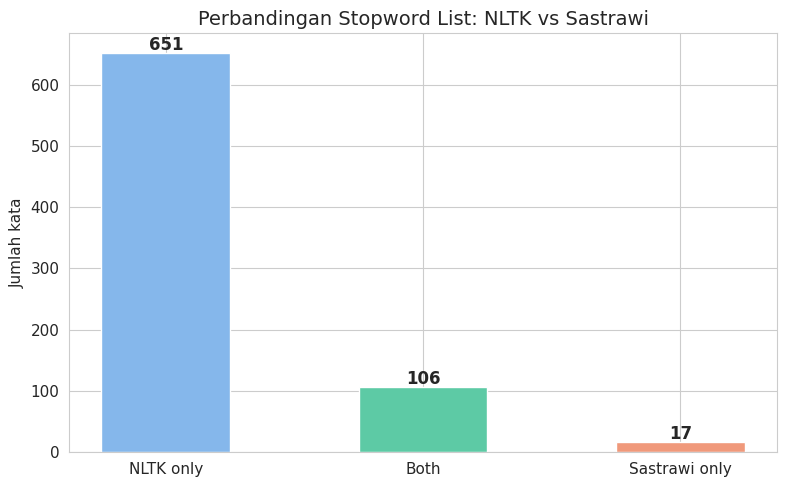

In [ ]:
# Visualisasi overlap
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['NLTK only', 'Both', 'Sastrawi only']
values = [len(only_nltk), len(overlap), len(only_sastrawi)]
colors = ['#85B7EB', '#5DCAA5', '#F0997B']

bars = ax.bar(categories, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=12, fontweight='bold')

ax.set_title('Perbandingan Stopword List: NLTK vs Sastrawi', fontsize=14)
ax.set_ylabel('Jumlah kata')
plt.tight_layout()
plt.show()

## 4. Cek Kata Umum yang Belum Tercakup Stopwords

Masalah dengan stopword list default: keduanya dibuat untuk Bahasa Indonesia formal.
Review GoPay menggunakan bahasa informal, slang, singkatan, dan partikel
yang tidak ada di list manapun. Mari identifikasi kata-kata ini.

In [ ]:
# Gabungkan semua token
all_tokens = [t for tokens in df['tokens'] for t in tokens]
total_tokens = len(all_tokens)
word_freq = Counter(all_tokens)

print(f'Total tokens            : {total_tokens:,}')
print(f'Unique words            : {len(word_freq):,}')
print(f'Average tokens/review   : {total_tokens / len(df):.1f}')

Total tokens            : 1,053,490
Unique words            : 12,349
Average tokens/review   : 5.0


In [ ]:
# TOP 50 kata paling sering SEBELUM stopword removal
top50_before = word_freq.most_common(50)

print('TOP 50 kata paling sering (SEBELUM stopword removal):')
print('=' * 55)

combined_sw = nltk_sw | sastrawi_sw

df_top50 = pd.DataFrame(top50_before, columns=['word', 'freq'])
df_top50['in_stopwords'] = df_top50['word'].apply(
    lambda w: 'YES' if w in combined_sw else 'NO'
)
df_top50['pct'] = (df_top50['freq'] / total_tokens * 100).round(2)
df_top50.index += 1

print(df_top50.to_string())
print()

not_covered = df_top50[df_top50['in_stopwords'] == 'NO']
print(f'Kata di TOP 50 yang BELUM tercakup stopwords: {len(not_covered)}')
print(f'Kata-kata tersebut: {list(not_covered["word"])}')

TOP 50 kata paling sering (SEBELUM stopword removal):
         word   freq in_stopwords   pct
1       mudah  25831           NO  2.45
2       bagus  24547           NO  2.33
3   transaksi  20428           NO  1.94
4       bantu  19798           NO  1.88
5       pakai  19626           NO  1.86
6       saldo  18604           NO  1.77
7       masuk  17561           NO  1.67
8      banget  17009           NO  1.61
9       bayar  15532           NO  1.47
10     mantap  13779           NO  1.31
11   transfer  13138           NO  1.25
12        top  11602           NO  1.10
13      cepat  11547           NO  1.10
14      kasih  11320           NO  1.07
15       uang  10780           NO  1.02
16     pinjam   8904           NO  0.85
17       aman   7654           NO  0.73
18       akun   7197           NO  0.68
19       baik   7145          YES  0.68
20       beli   6935           NO  0.66
21       moga   6861           NO  0.65
22       kalo   6635           NO  0.63
23       suka   6072      

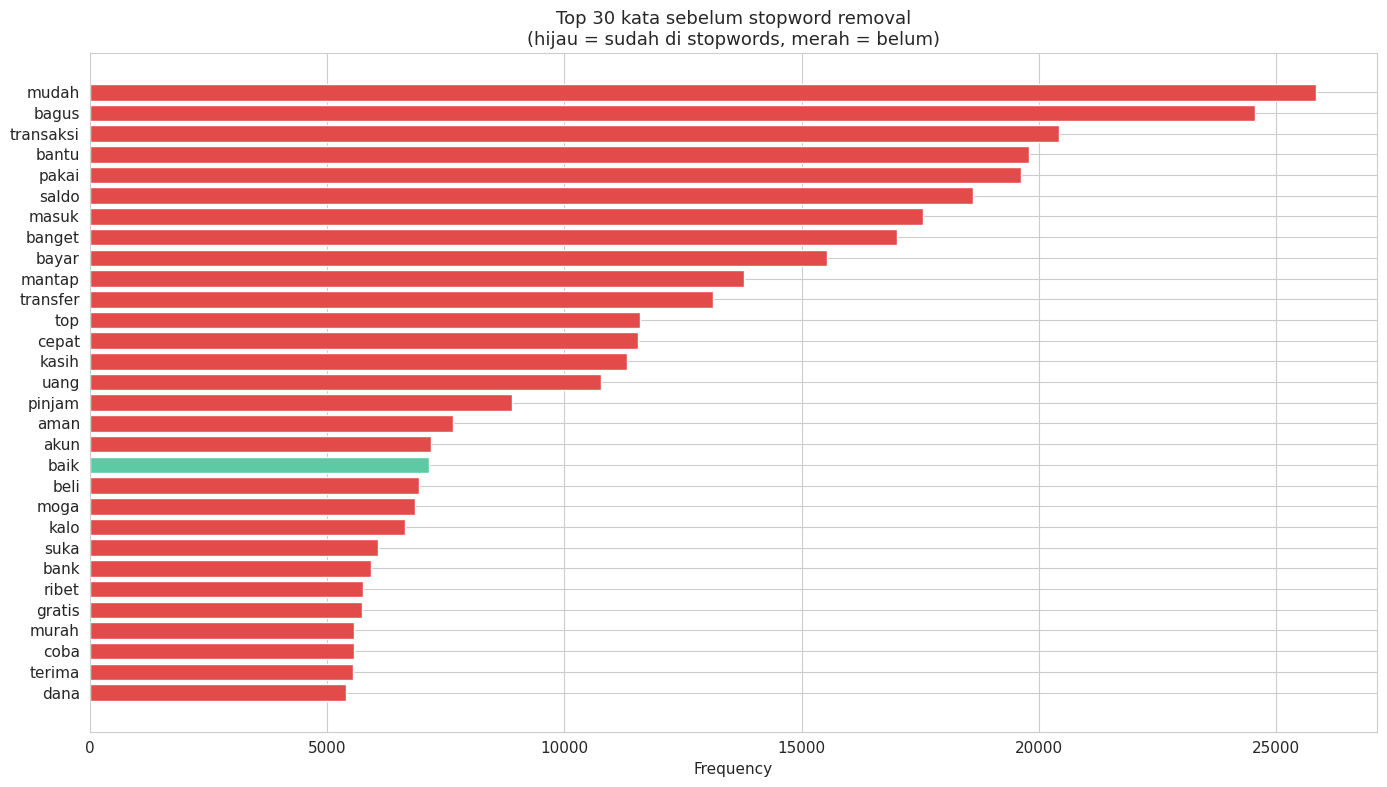

In [ ]:
# Visualisasi: TOP 30 sebelum stopword removal
# Warnai berdasarkan ada/tidaknya di stopword list
top30 = word_freq.most_common(30)
words_30, freqs_30 = zip(*top30)
colors_30 = ['#5DCAA5' if w in combined_sw else '#E24B4A' for w in words_30]

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(30), freqs_30, color=colors_30, edgecolor='white')
ax.set_yticks(range(30))
ax.set_yticklabels(words_30)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 kata sebelum stopword removal\n(hijau = sudah di stopwords, merah = belum)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Stopword Removal: 3-Layer Approach

Karena default stopwords tidak cukup untuk bahasa informal di review,
kita gunakan pendekatan 3 layer:

| Layer | Sumber | Cakupan |
|-------|--------|---------|
| 1 | NLTK Indonesian | Kata fungsi formal (yang, dan, di, ke, dari, dll.) |
| 2 | Sastrawi | Kata fungsi tambahan dari stemmer |
| 3 | Domain custom | Kata spesifik GoPay + partikel informal |

In [ ]:
# Layer 3: Domain-specific stopwords
# Kata yang spesifik untuk dataset GoPay dan tidak membawa sinyal sentimen
domain_sw = {
    # Nama brand/app (muncul di hampir semua review)
    'gopay', 'gojek',
    'aplikasi', 'app', 'application',

    # Partikel bahasa informal (tidak ada di NLTK/Sastrawi)
    'nya', 'sih', 'deh', 'loh', 'nih', 'lah', 'kok',
    'yah', 'wah', 'tuh', 'gitu', 'gini',
}

all_stopwords = nltk_sw | sastrawi_sw | domain_sw

print(f'Layer 1 (NLTK)     : {len(nltk_sw)} kata')
print(f'Layer 2 (Sastrawi) : {len(sastrawi_sw)} kata')
print(f'Layer 3 (Domain)   : {len(domain_sw)} kata')
print(f'Total gabungan     : {len(all_stopwords)} kata')

Layer 1 (NLTK)     : 757 kata
Layer 2 (Sastrawi) : 123 kata
Layer 3 (Domain)   : 17 kata
Total gabungan     : 788 kata


In [ ]:
# Terapkan stopword removal
def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

before_count = sum(len(t) for t in df['tokens'])
after_count = sum(len(t) for t in df['tokens_no_sw'])

print(f'Tokens sebelum stopword removal : {before_count:,}')
print(f'Tokens sesudah stopword removal : {after_count:,}')
print(f'Token dihapus                   : {before_count - after_count:,} ({(before_count - after_count) / before_count * 100:.1f}%)')

Tokens sebelum stopword removal : 1,053,490
Tokens sesudah stopword removal : 1,014,479
Token dihapus                   : 39,011 (3.7%)


## 6. Frequent Words Analysis (sesudah stopword removal)

Sekarang kita lihat kata-kata yang paling sering muncul sesudah stopword removal.
Dari sini kita identifikasi kata yang lolos tapi seharusnya tidak membawa makna
penting untuk analisis sentimen.

In [ ]:
# Hitung frekuensi sesudah stopword removal
tokens_after_sw = [t for tokens in df['tokens_no_sw'] for t in tokens]
freq_after_sw = Counter(tokens_after_sw)

# TOP 100
top100 = freq_after_sw.most_common(100)

print('TOP 100 kata paling sering (SESUDAH 3-layer stopword removal):')
print('=' * 50)
df_top100 = pd.DataFrame(top100, columns=['word', 'freq'])
df_top100.index += 1

# Tampilkan dalam 2 kolom
col_a = df_top100.iloc[:50].reset_index(drop=True)
col_b = df_top100.iloc[50:].reset_index(drop=True)
col_a.columns = ['word (1-50)', 'freq']
col_b.columns = ['word (51-100)', 'freq ']
print(pd.concat([col_a, col_b], axis=1).to_string(index=False))

TOP 100 kata paling sering (SESUDAH 3-layer stopword removal):
word (1-50)  freq word (51-100)  freq 
      mudah 25831         tarik   3308
      bagus 24547         lapor   3054
  transaksi 20428       gampang   3027
      bantu 19798           jam   2951
      pakai 19626      cashback   2945
      saldo 18604         hasil   2940
      masuk 17561        sukses   2937
     banget 17009         orang   2937
      bayar 15532         bikin   2916
     mantap 13779       manfaat   2908
   transfer 13138         kayak   2895
        top 11602      langsung   2804
      cepat 11547         butuh   2784
      kasih 11320          buka   2776
       uang 10780         mohon   2710
     pinjam  8904       praktis   2659
       aman  7654          good   2614
       akun  7197        blokir   2480
       beli  6935        daftar   2471
       moga  6861        ganggu   2460
       kalo  6635           aju   2330
       suka  6072         suruh   2325
       bank  5920         login   2282
 

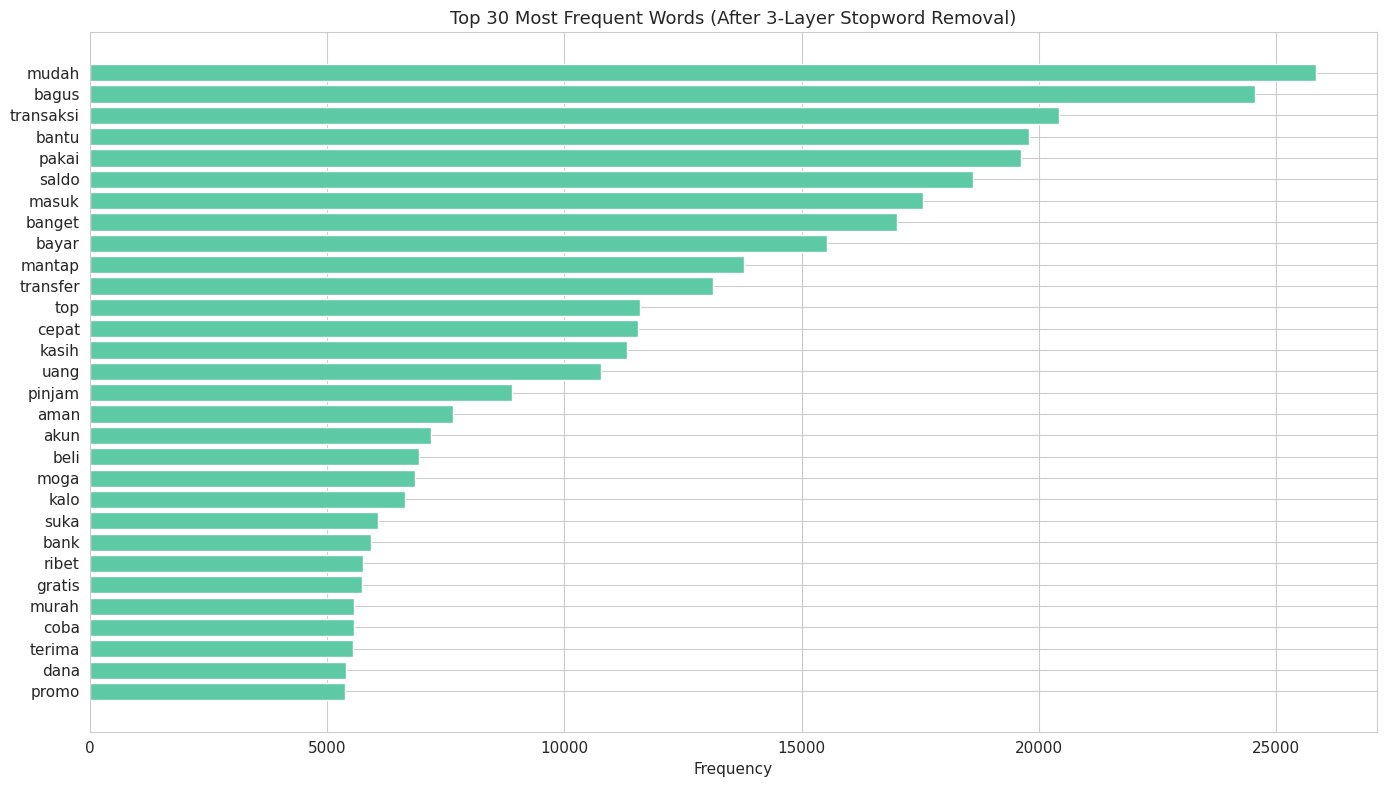

In [ ]:
# Visualisasi TOP 30 sesudah stopword removal
top30_after = freq_after_sw.most_common(30)
words_a, freqs_a = zip(*top30_after)

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(30), freqs_a, color='#5DCAA5', edgecolor='white')
ax.set_yticks(range(30))
ax.set_yticklabels(words_a)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words (After 3-Layer Stopword Removal)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Identifikasi Noise Words dari Frequent Words

Dari TOP 100 di atas, kita identifikasi kata-kata yang:
- Tidak membawa sinyal sentimen (bukan positif maupun negatif)
- Merupakan singkatan, filler, atau varian kata yang sudah tercakup

Kata yang **tetap dipertahankan** (tidak ditambahkan ke stopwords):
- Kata bermuatan emosi: bagus, buruk, lambat, cepat, kecewa, error, dll.
- Kata yang relevan untuk sentimen meskipun frekuensinya tinggi

In [ ]:
# Noise words yang diidentifikasi dari analisis TOP 100
# Setiap kata diberi komentar alasan kenapa dianggap noise

found_noise_words = {
    # --- Singkatan & simbol ---
    'rp',           # simbol rupiah, konteks numerik
    'tf',           # singkatan 'transfer' yang tidak baku
    'wdp',          # singkatan tidak jelas
    'cs',           # 'customer service', terlalu umum
    'min',          # panggilan 'admin/mimin', tidak informatif

    # --- Varian kata yang sudah tercakup ---
    'terimakasih',  # varian 'terima kasih'
    'aplikasinya',  # varian 'aplikasi' (sudah di domain_sw)
    'gue',          # varian 'saya' (harusnya sudah di-normalize)
    'gua',          # varian 'saya'
    'ku',           # sufiks/kata ganti
    'hp',           # 'handphone', konteks netral

    # --- Filler & partikel ---
    'pokoknya',     # filler tanpa kandungan sentimen
    'mulu',         # filler ('terus-menerus'), ambigu
    'oke',          # respon netral

    # --- Kata konteks netral untuk GoPay ---
    'apk',          # varian 'aplikasi'
    'up',           # 'top up' terpotong, tidak berdiri sendiri
    'kali',         # penanda frekuensi netral
    'bintang',      # artefak dari sistem rating, bukan opini
}

print(f'Noise words yang ditemukan: {len(found_noise_words)} kata')
print()
for w in sorted(found_noise_words):
    freq_val = freq_after_sw.get(w, 0)
    print(f'  {w:20s} (frekuensi: {freq_val:,})')

Noise words yang ditemukan: 18 kata

  apk                  (frekuensi: 3)
  aplikasinya          (frekuensi: 0)
  bintang              (frekuensi: 227)
  cs                   (frekuensi: 0)
  gua                  (frekuensi: 5)
  gue                  (frekuensi: 0)
  hp                   (frekuensi: 0)
  kali                 (frekuensi: 577)
  ku                   (frekuensi: 0)
  min                  (frekuensi: 3)
  mulu                 (frekuensi: 0)
  oke                  (frekuensi: 106)
  pokoknya             (frekuensi: 0)
  rp                   (frekuensi: 0)
  terimakasih          (frekuensi: 0)
  tf                   (frekuensi: 3)
  up                   (frekuensi: 0)
  wdp                  (frekuensi: 0)


In [ ]:
# Contoh kata yang TIDAK ditambahkan ke stopwords (tetap dipertahankan)
# Karena membawa sinyal sentimen yang penting

kept_words = ['bagus', 'buruk', 'lambat', 'cepat', 'kecewa', 'error',
              'mantap', 'susah', 'mudah', 'gagal', 'suka', 'benci']

print('Kata yang TETAP dipertahankan (membawa sinyal sentimen):')
print('=' * 55)
for w in kept_words:
    freq_val = freq_after_sw.get(w, 0)
    if freq_val > 0:
        print(f'  {w:20s} (frekuensi: {freq_val:,})')

Kata yang TETAP dipertahankan (membawa sinyal sentimen):
  bagus                (frekuensi: 24,547)
  buruk                (frekuensi: 1,596)
  lambat               (frekuensi: 1,133)
  cepat                (frekuensi: 11,547)
  kecewa               (frekuensi: 4,275)
  error                (frekuensi: 1,293)
  mantap               (frekuensi: 13,779)
  susah                (frekuensi: 3,505)
  mudah                (frekuensi: 25,831)
  gagal                (frekuensi: 3,361)
  suka                 (frekuensi: 6,072)
  benci                (frekuensi: 52)


## 8. Tambahkan Noise Words ke Stopword List

In [ ]:
# Update stopword list
stopwords_before = len(all_stopwords)
all_stopwords.update(found_noise_words)
stopwords_after = len(all_stopwords)

print(f'Stopwords sebelum penambahan : {stopwords_before}')
print(f'Noise words ditambahkan      : {len(found_noise_words)}')
print(f'Stopwords sesudah penambahan : {stopwords_after}')

# Re-apply stopword removal
df['tokens_updated'] = df['tokens'].apply(remove_stopwords)

after_update = sum(len(t) for t in df['tokens_updated'])
print(f'\nTokens sesudah update : {after_update:,}')
print(f'Token tambahan dihapus: {after_count - after_update:,}')

Stopwords sebelum penambahan : 788
Noise words ditambahkan      : 18
Stopwords sesudah penambahan : 806

Tokens sesudah update : 1,013,555
Token tambahan dihapus: 924


## 9. Evaluasi: Sebelum vs Sesudah Penambahan Stopwords

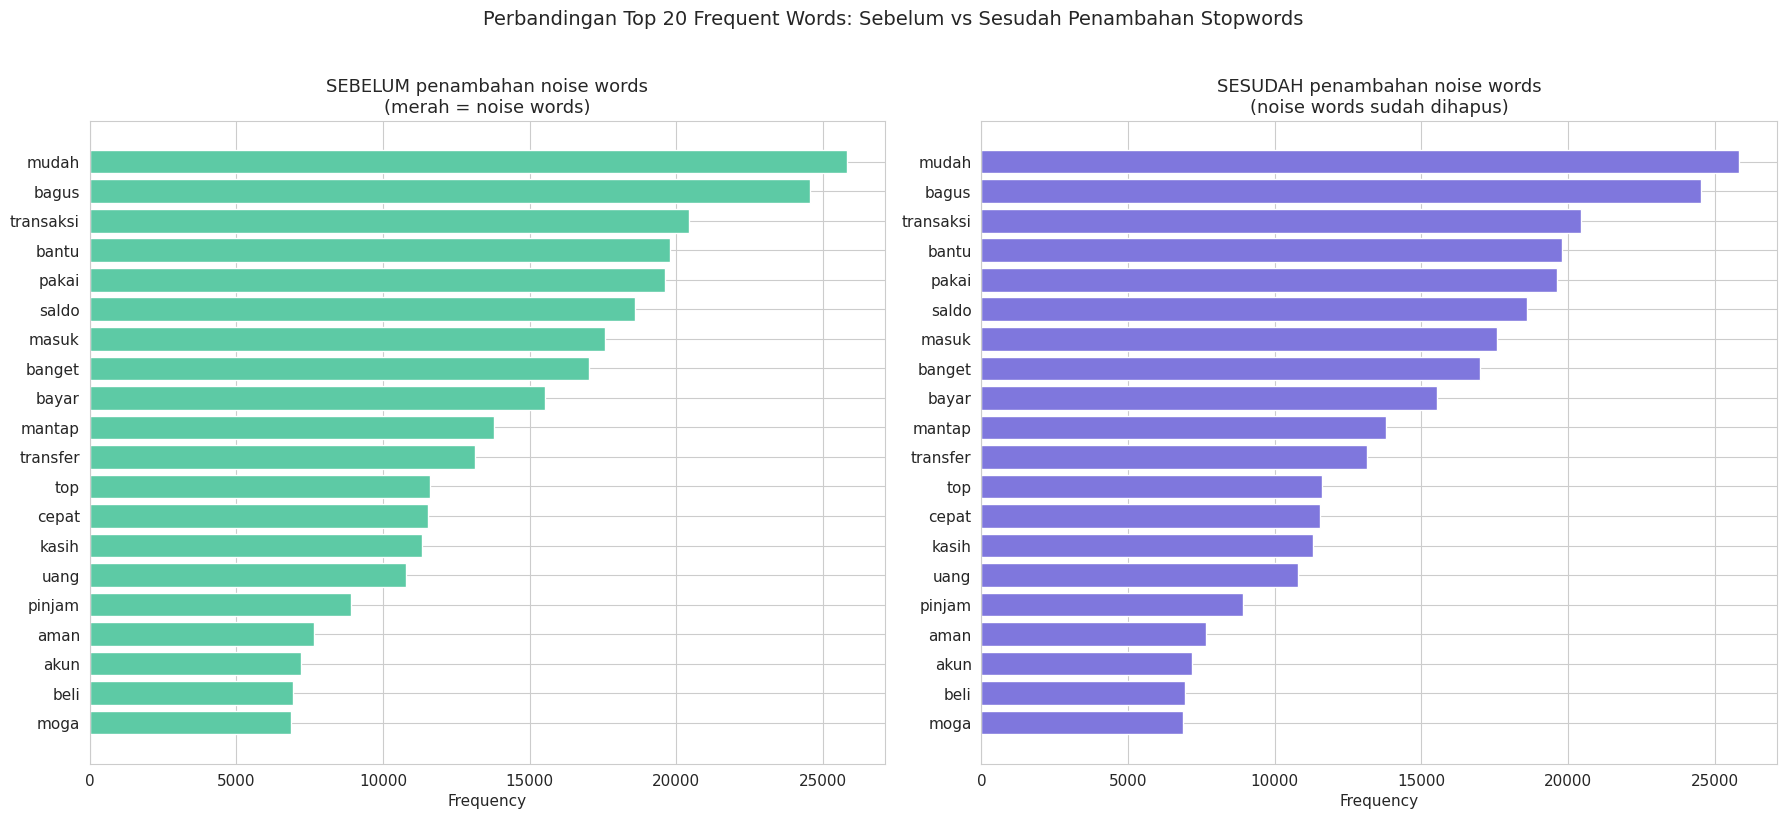

In [ ]:
# Hitung ulang frekuensi sesudah update
tokens_updated = [t for tokens in df['tokens_updated'] for t in tokens]
freq_updated = Counter(tokens_updated)

# Perbandingan TOP 20: sebelum vs sesudah
top20_before = freq_after_sw.most_common(20)
top20_after = freq_updated.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Sebelum
w_b, f_b = zip(*top20_before)
colors_b = ['#E24B4A' if w in found_noise_words else '#5DCAA5' for w in w_b]
axes[0].barh(range(20), f_b, color=colors_b, edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(w_b)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency')
axes[0].set_title('SEBELUM penambahan noise words\n(merah = noise words)', fontsize=13)

# Sesudah
w_a, f_a = zip(*top20_after)
axes[1].barh(range(20), f_a, color='#7F77DD', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(w_a)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title('SESUDAH penambahan noise words\n(noise words sudah dihapus)', fontsize=13)

plt.suptitle('Perbandingan Top 20 Frequent Words: Sebelum vs Sesudah Penambahan Stopwords',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Tabel perbandingan side-by-side
print(f'{"Rank":>4}  {"SEBELUM":20s} {"Freq":>8}  |  {"SESUDAH":20s} {"Freq":>8}')
print('-' * 70)
for rank in range(20):
    w1, f1 = top20_before[rank]
    w2, f2 = top20_after[rank]
    marker = ' << NOISE' if w1 in found_noise_words else ''
    print(f'{rank+1:>4}  {w1:20s} {f1:>8,}  |  {w2:20s} {f2:>8,}{marker}')

Rank  SEBELUM                  Freq  |  SESUDAH                  Freq
----------------------------------------------------------------------
   1  mudah                  25,831  |  mudah                  25,831
   2  bagus                  24,547  |  bagus                  24,547
   3  transaksi              20,428  |  transaksi              20,428
   4  bantu                  19,798  |  bantu                  19,798
   5  pakai                  19,626  |  pakai                  19,626
   6  saldo                  18,604  |  saldo                  18,604
   7  masuk                  17,561  |  masuk                  17,561
   8  banget                 17,009  |  banget                 17,009
   9  bayar                  15,532  |  bayar                  15,532
  10  mantap                 13,779  |  mantap                 13,779
  11  transfer               13,138  |  transfer               13,138
  12  top                    11,602  |  top                    11,602
  13  cepat        

## 10. Ringkasan Stopword List Final

Daftar lengkap semua sumber stopwords yang digunakan.

In [ ]:
print('RINGKASAN STOPWORD LIST')
print('=' * 60)
print()
print(f'Layer 1: NLTK Indonesian         = {len(nltk_sw):>4} kata')
print(f'Layer 2: Sastrawi                = {len(sastrawi_sw):>4} kata')
print(f'Layer 3: Domain custom (GoPay)   = {len(domain_sw):>4} kata')
print(f'Layer 4: Noise words (data-driven) = {len(found_noise_words):>4} kata')
print(f'{'':->60}')
print(f'Total (union, tanpa duplikat)    = {len(all_stopwords):>4} kata')
print()
print('Layer 3 - Domain custom:')
for w in sorted(domain_sw):
    print(f'  {w}')
print()
print('Layer 4 - Noise words (dari frequent words analysis):')
for w in sorted(found_noise_words):
    print(f'  {w}')

RINGKASAN STOPWORD LIST

Layer 1: NLTK Indonesian         =  757 kata
Layer 2: Sastrawi                =  123 kata
Layer 3: Domain custom (GoPay)   =   17 kata
Layer 4: Noise words (data-driven) =   18 kata
------------------------------------------------------------
Total (union, tanpa duplikat)    =  806 kata

Layer 3 - Domain custom:
  aplikasi
  app
  application
  deh
  gini
  gitu
  gojek
  gopay
  kok
  lah
  loh
  nih
  nya
  sih
  tuh
  wah
  yah

Layer 4 - Noise words (dari frequent words analysis):
  apk
  aplikasinya
  bintang
  cs
  gua
  gue
  hp
  kali
  ku
  min
  mulu
  oke
  pokoknya
  rp
  terimakasih
  tf
  up
  wdp


## 11. Kesimpulan

### Temuan Utama

1. **Default stopwords tidak cukup** untuk dataset review Bahasa Indonesia informal. NLTK dan Sastrawi hanya mencakup kata fungsi formal, sementara review penuh dengan partikel informal (sih, deh, nih, kok) dan singkatan (tf, cs, hp).

2. **Pendekatan 3+1 layer** efektif:
   - Layer 1-2 (NLTK + Sastrawi) menangani kata fungsi standar
   - Layer 3 (domain custom) menangani nama brand dan partikel informal
   - Layer 4 (data-driven noise words) menangani artefak spesifik dataset yang teridentifikasi dari analisis frekuensi

3. **Prinsip penting:** tidak semua kata frekuensi tinggi harus jadi stopword. Kata seperti "bagus", "error", "lambat" meskipun sangat sering muncul, justru merupakan sinyal sentimen yang harus dipertahankan.

4. **19 noise words** berhasil diidentifikasi dan ditambahkan, membersihkan vocabulary dari kata-kata yang tidak informatif tanpa menghilangkan sinyal sentimen.

### Referensi

- Week2-Scrapping Apps Review MobileJKN (referensi colab dari dosen)
- NLTK Indonesian Stopwords (758 kata)
- PySastrawi Stopwords
- Salsabila et al. (2018) - kamus-alay Indonesian slang corpus